In [36]:
#Bibliotecas
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

#Função para a apresentação da imagem
def apresentaImg(imagem):
    img = plt.figure(figsize = (30,28))
    ax = img.add_subplot(111)
    ax.imshow(imagem, cmap = 'gray')

#Carregando as imagens
leite_comdensado = cv2.imread('leite_comdensado.jpg')
leite_comdensado = cv2.cvtColor(leite_comdensado, cv2.COLOR_BGR2GRAY)

pratileira_leite = cv2.imread('pratileira_leite.jpg')
pratileira_leite = cv2.cvtColor(pratileira_leite, cv2.COLOR_BGR2GRAY)

sift = cv2.xfeatures2d.SIFT_create()

kp1, des1 = sift.detectAndCompute(leite_comdensado, None)
kp2, des2 = sift.detectAndCompute(pratileira_leite, None)

In [37]:
FLANN_INDEX_KDTREEE = 0 

index_params = dict(algorithm = FLANN_INDEX_KDTREEE, trees = 5)
search_params = dict(checks = 50)

In [10]:
flann = cv2.FlannBasedMatcher(index_params, search_params)

In [38]:
matches = flann.knnMatch(des1, des2, k = 2)

In [39]:
good = []

for match1, match2 in matches:
    if match1.distance < 0.6*match2.distance:
        good.append([match1]) 

In [40]:
flann_matches = cv2.drawMatchesKnn(leite_comdensado, kp1, pratileira_leite, kp2, good, None, flags = 2)

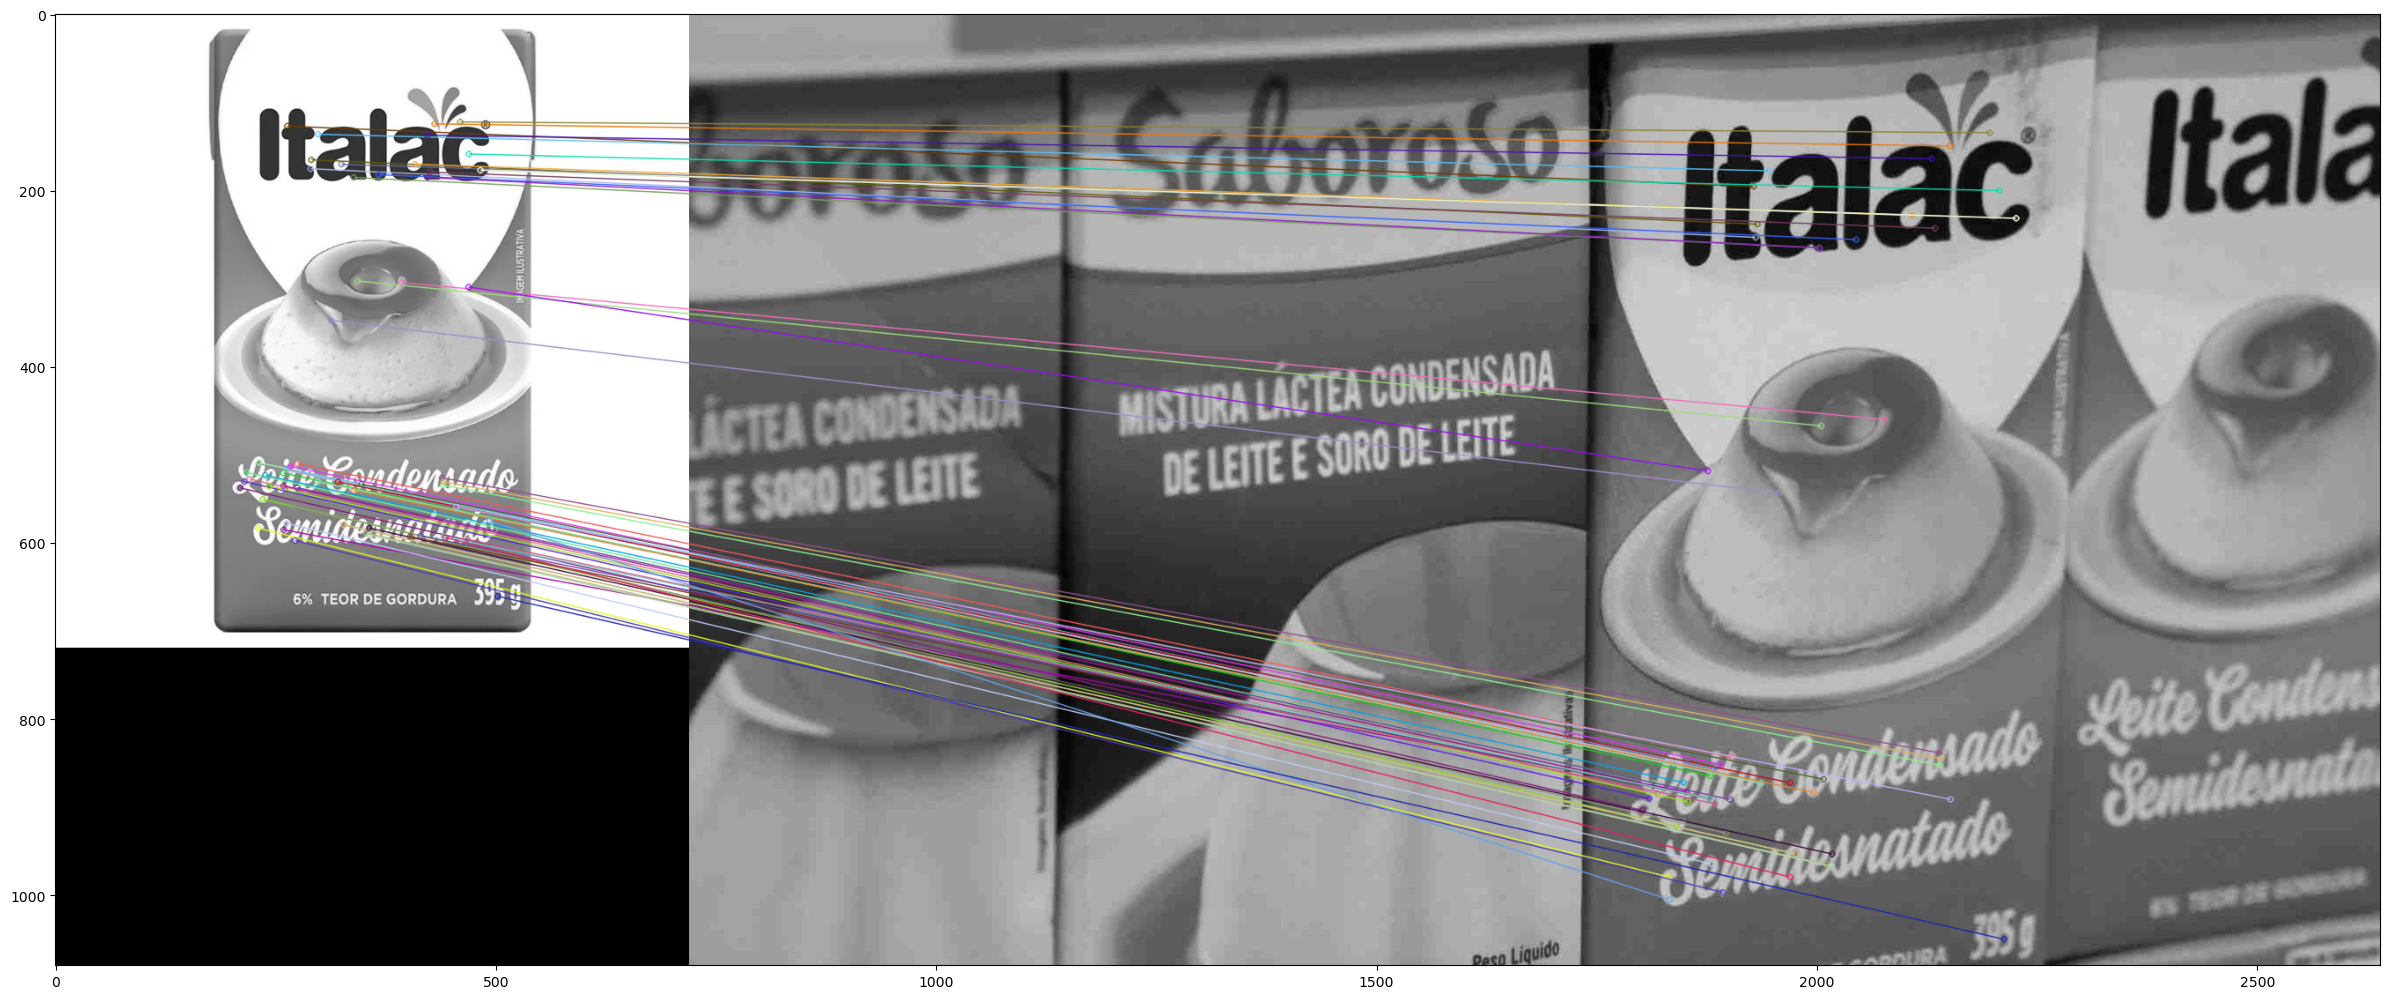

In [41]:
 apresentaImg(flann_matches)

In [42]:
matchesMask = [[0,0] for i in range(len(matches))]

In [43]:
#matchesMask

In [51]:
for i, (match1, match2) in enumerate(matches):
    if match1.distance < 0.75*match2.distance:
        matchesMask[i] = [1,0] 

In [58]:
draw_params = dict(matchColor = (0,255,0), singlePointColor = (255,0,0), matchesMask = matchesMask, flags = 0)

In [59]:
flann_matches = cv2.drawMatchesKnn(leite_comdensado, kp1, pratileira_leite, kp2, matches, None, **draw_params)

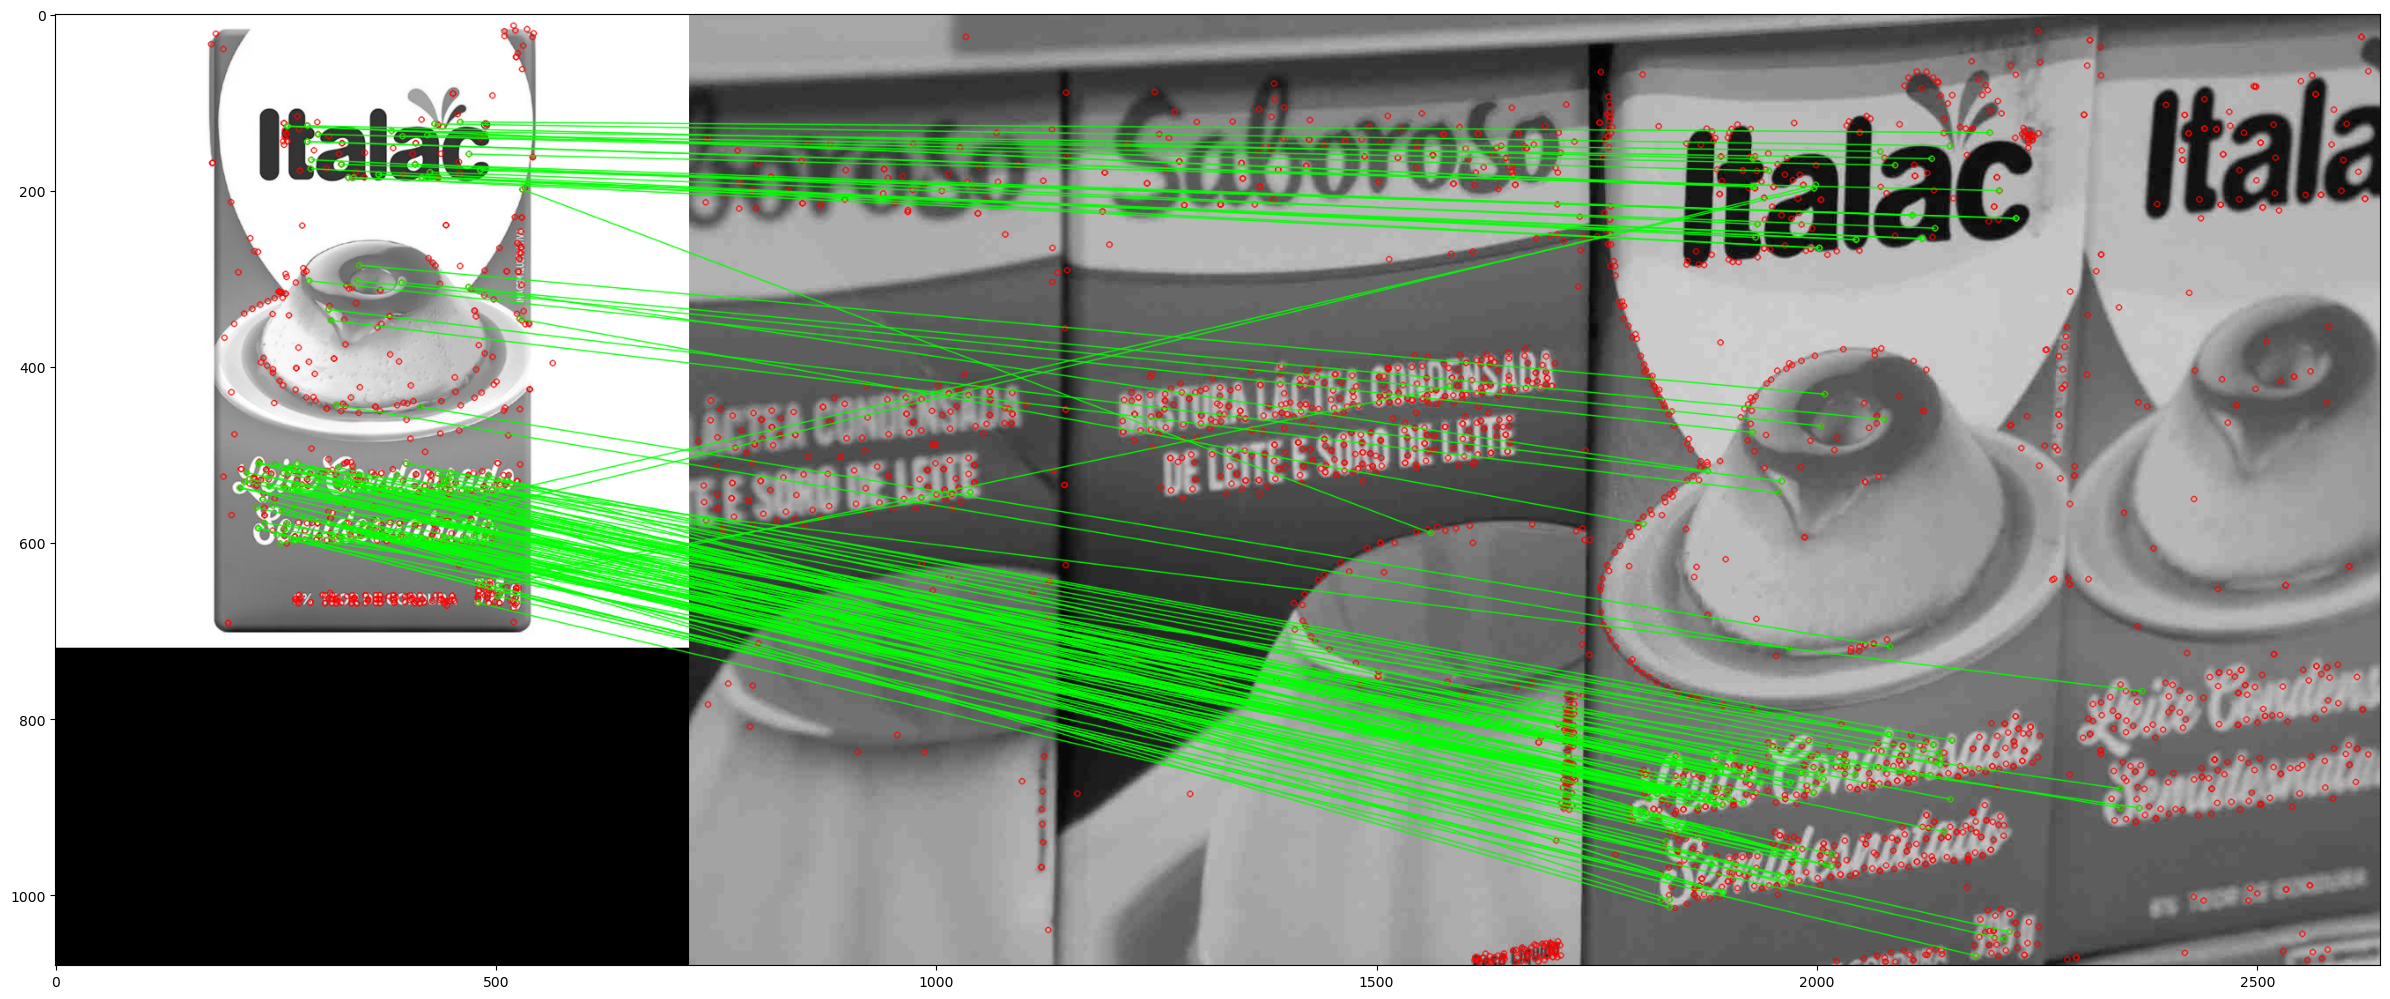

In [60]:
apresentaImg(flann_matches)